In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
gender_sub = pd.read_csv('data/gender_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Gender submission shape:", gender_sub.shape)
#数据读取

Train shape: (891, 12)
Test shape: (418, 11)
Gender submission shape: (418, 2)


In [27]:
def missing_report(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'count': missing, 'percent': missing_pct})
    report = report[report['count'] > 0].sort_values('percent', ascending=False)
    print(f" {name} 缺失值情况")
    print(report)
    print()

missing_report(train, "Train")
missing_report(test, "Test")
#检查缺失值

 Train 缺失值情况
          count  percent
Cabin       687    77.10
Age         177    19.87
Embarked      2     0.22

 Test 缺失值情况
       count  percent
Cabin    327    78.23
Age       86    20.57
Fare       1     0.24



Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


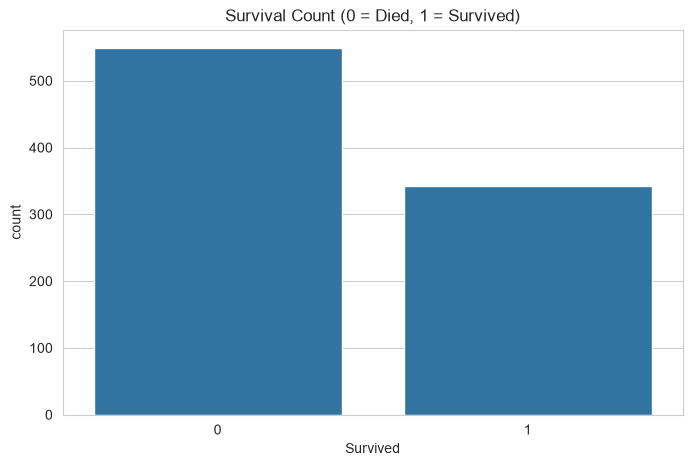

In [28]:
print(train['Survived'].value_counts())
print(train['Survived'].value_counts(normalize=True))

sns.countplot(data=train, x='Survived')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.show()
#生还数量分布

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


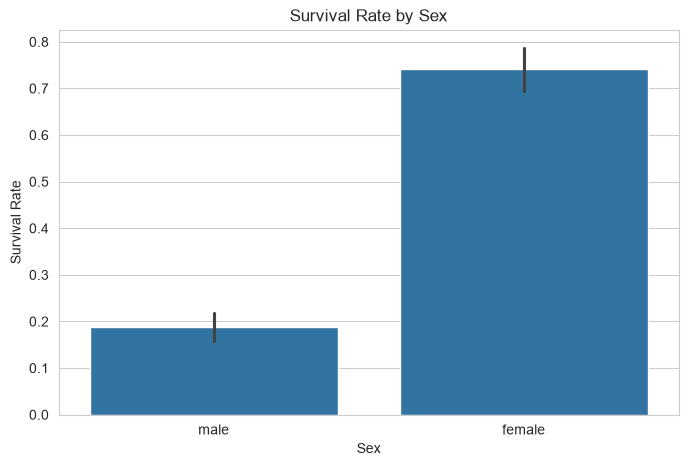

In [30]:
survival_by_sex = train.groupby('Sex')['Survived'].mean()
print(survival_by_sex)

sns.barplot(data=train, x='Sex', y='Survived')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()
#性别与生还率关系

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


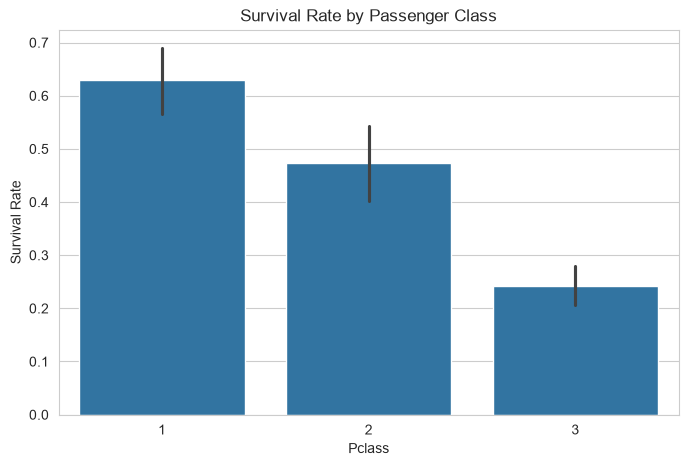

In [32]:
survival_by_class = train.groupby('Pclass')['Survived'].mean()
print(survival_by_class)

sns.barplot(data=train, x='Pclass', y='Survived')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()
#船舱等级与生还率关系

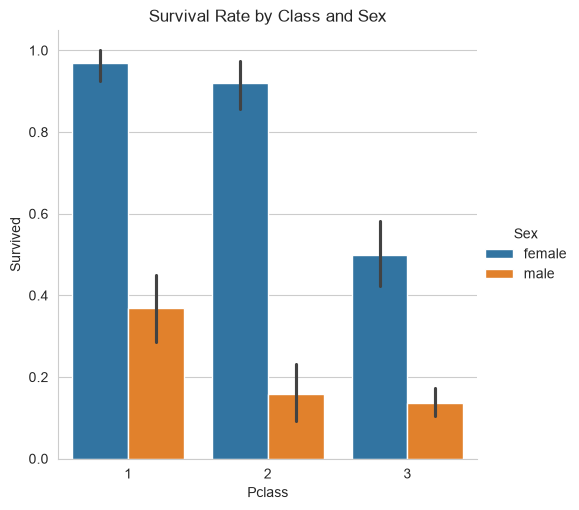

In [34]:
sns.catplot(data=train, x='Pclass', y='Survived', hue='Sex', kind='bar')
plt.title('Survival Rate by Class and Sex')
plt.show()
#结合性别与船舱等级的生还率关系

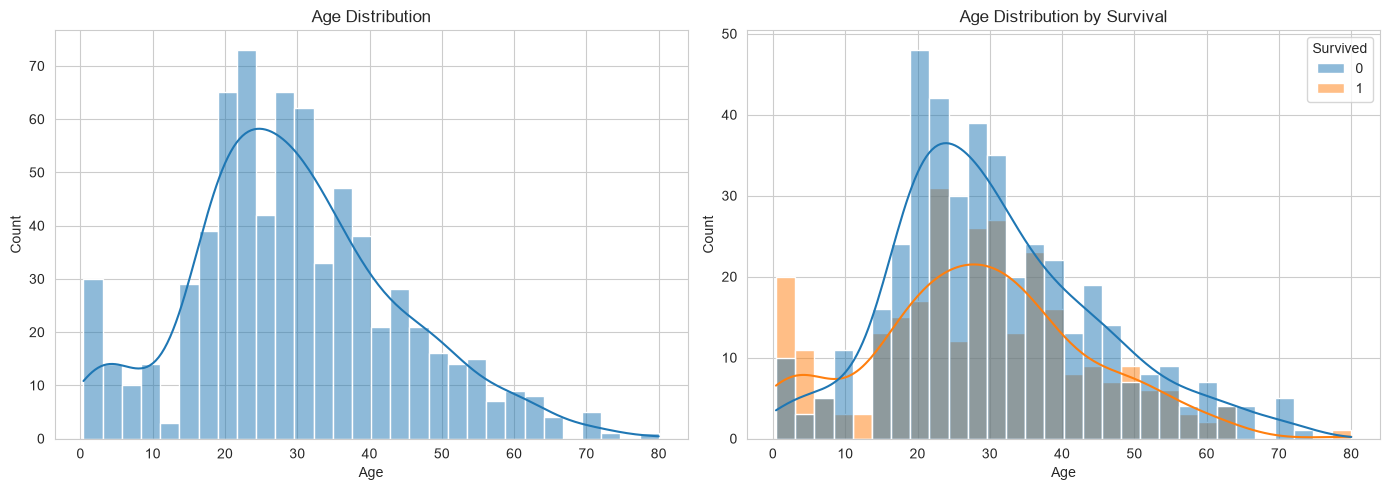

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#年龄分布图
sns.histplot(data=train, x='Age', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

#联系生还率的年龄分布图
sns.histplot(data=train, x='Age', hue='Survived', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Age Distribution by Survival')

plt.tight_layout()
plt.show()
#年龄分布与生还率关系

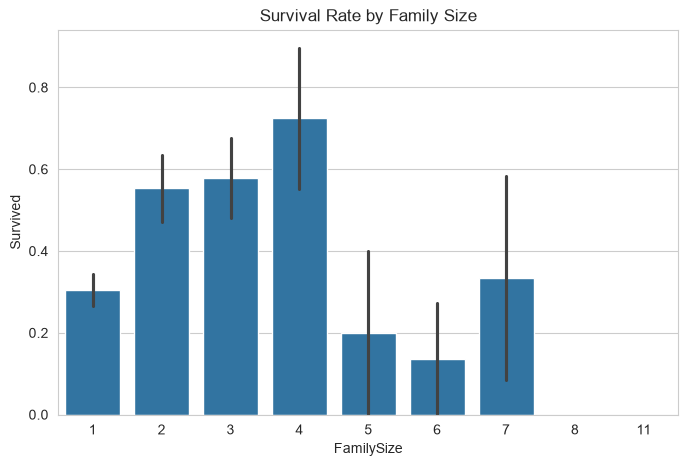

In [39]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

sns.barplot(data=train, x='FamilySize', y='Survived')
plt.title('Survival Rate by Family Size')
plt.show()
#家庭规模与生还率关系

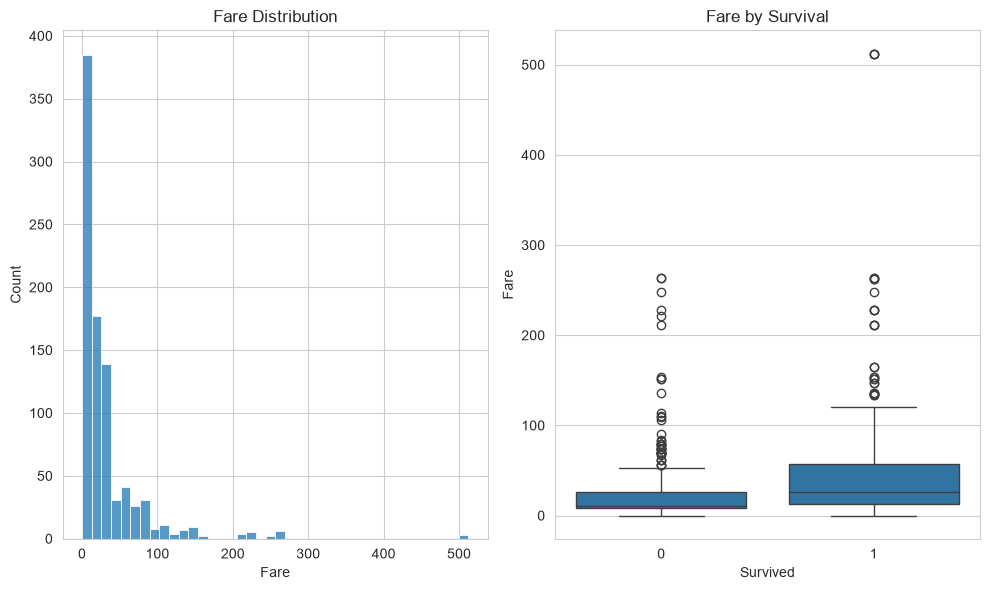

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

sns.histplot(data=train, x='Fare', bins=40, ax=axes[0])
axes[0].set_title('Fare Distribution')

sns.boxplot(data=train, x='Survived', y='Fare', ax=axes[1])
axes[1].set_title('Fare by Survival')

plt.tight_layout()
plt.show()
#票价与生还率关系

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


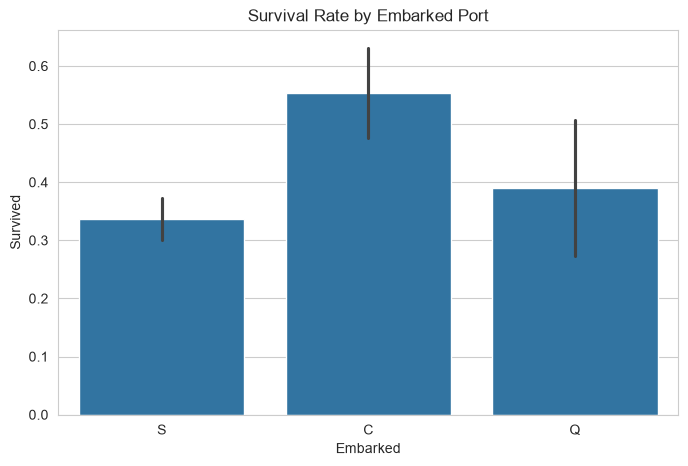

In [47]:
print(train['Embarked'].value_counts())

sns.barplot(data=train, x='Embarked', y='Survived')
plt.title('Survival Rate by Embarked Port')
plt.show()
#登船港口与生还率关系

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


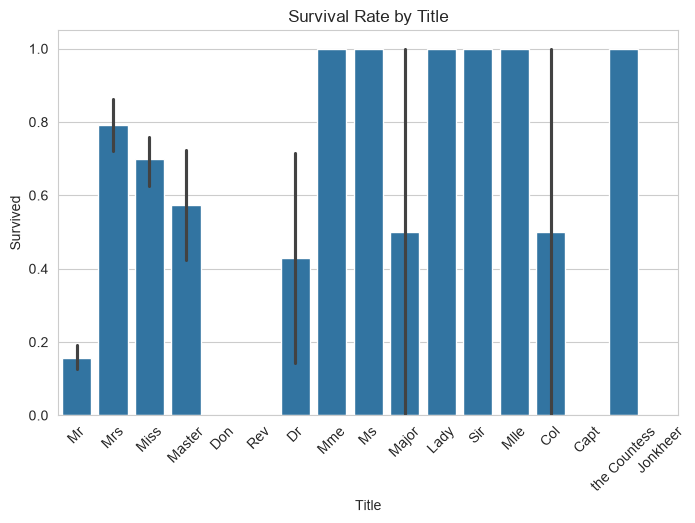

In [49]:
train['Title'] = train['Name'].str.extract(r',\s*([^\.]*)\.')
print(train['Title'].value_counts())

sns.barplot(data=train, x='Title', y='Survived')
plt.xticks(rotation=45)
plt.title('Survival Rate by Title')
plt.show()
#头衔与生还率关系

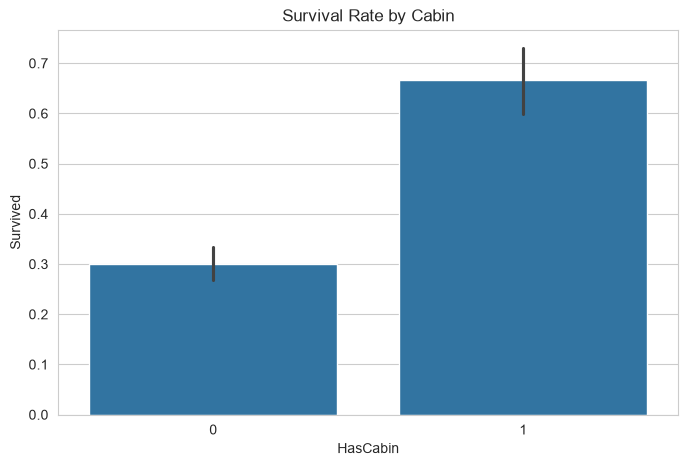

In [53]:
train['HasCabin'] = train['Cabin'].notnull().astype(int)

sns.barplot(data=train, x='HasCabin', y='Survived')
plt.title('Survival Rate by Cabin')
plt.show()
#舱位记录与生还率关系

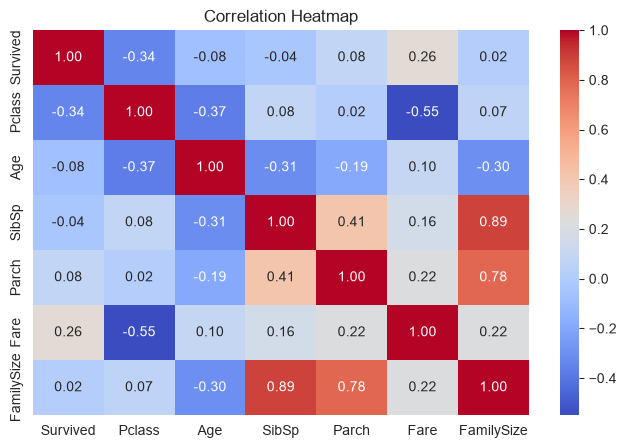

In [55]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
corr = train[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
#相关性热力图